In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 96.2 MB/s eta 0:00:00


Starting Optimized QNN Pipeline...
PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: Tesla T4

⚡ ULTRA FAST MODE

Loading data from: /kaggle/input/newdatasetransapfeatureextracted/RANSAP_win7-120gb-ssd_12CLASS.npy
Loaded data shape: (303481, 6)
Subsampled to 60696 samples (20%)

Training set: 17414 samples
Test set: 4354 samples

Training ensemble of 2 models...

--- Model 1/2 ---

Training for 30 epochs...
Epoch 10/30: Loss=0.6177, Val Acc=0.8165
Epoch 20/30: Loss=0.4892, Val Acc=0.8852
Epoch 30/30: Loss=0.4557, Val Acc=0.9030
Model 1 validation accuracy: 0.9058

--- Model 2/2 ---

Training for 30 epochs...
Epoch 10/30: Loss=0.5460, Val Acc=0.8519
Epoch 20/30: Loss=0.4438, Val Acc=0.9093
Epoch 30/30: Loss=0.4284, Val Acc=0.9167
Model 2 validation accuracy: 0.9173


Evaluating ensemble on test set...

RESULTS
Test Accuracy: 0.9192
F1 Score: 0.9142
Time taken: 0.3 minutes

Classification Report:
              precision    recall  f1-score   support

      Benign       0.88      0.9

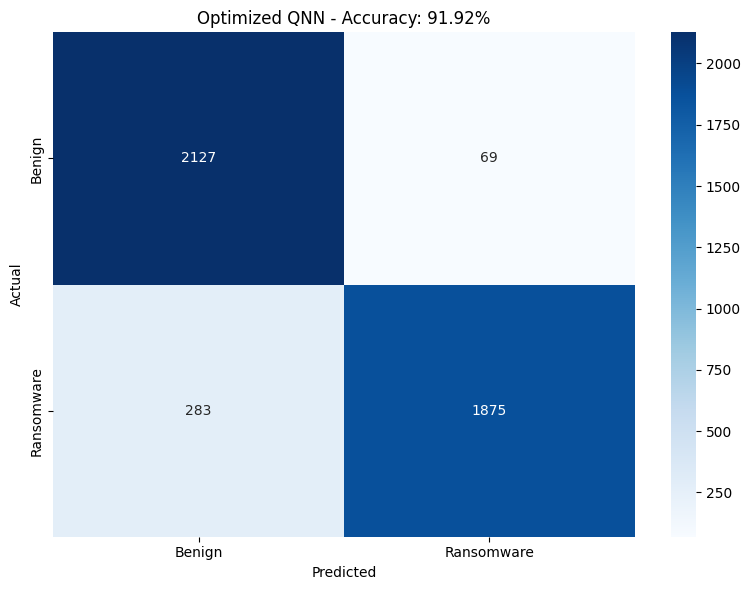


✅ Pipeline completed successfully!
   Consider using FAST or BALANCED mode for higher accuracy


In [2]:
#!/usr/bin/env python3
"""
Optimized QNN for Ransomware Detection
Fast implementation that runs in 15-60 minutes instead of 12+ hours
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import warnings
warnings.filterwarnings('ignore')

# Set seeds
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# ============ CONFIGURATION ============
print("Starting Optimized QNN Pipeline...")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Class definitions
BENIGN_CLASSES_12 = {0, 3, 4, 7, 11}
RANSOMWARE_CLASSES_12 = {1, 2, 5, 6, 8, 9, 10}

# ============ FAST QUANTUM LAYER ============
class FastQuantumLayer(nn.Module):
    """Fast quantum-inspired layer without actual quantum simulation"""
    def __init__(self, n_qubits, n_layers):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        
        # Quantum-inspired parameters
        self.rotations = nn.Parameter(torch.randn(n_layers, n_qubits, 3) * 0.1)
        self.entanglements = nn.Parameter(torch.randn(n_layers, n_qubits, n_qubits) * 0.1)
        self.measurements = nn.Parameter(torch.randn(n_qubits, 3) * 0.1)
        
    def forward(self, x):
        batch_size = x.shape[0]
        
        # Initialize "quantum state"
        state = x.clone()
        
        # Simulate quantum evolution
        for layer in range(self.n_layers):
            # Rotations
            rot = torch.tanh(self.rotations[layer])
            state = state * torch.cos(rot[:, 0]) + state.roll(1, dims=1) * torch.sin(rot[:, 1])
            
            # Entanglement
            ent = torch.sigmoid(self.entanglements[layer])
            state = state + F.linear(state, ent)
            
            # Normalize
            state = F.normalize(state, p=2, dim=1)
        
        # Measurements
        z_exp = state * self.measurements[:, 0]
        x_exp = state.roll(1, dims=1) * self.measurements[:, 1]
        y_exp = (state + state.roll(1, dims=1)) * self.measurements[:, 2]
        
        # Combine measurements
        output = torch.cat([z_exp, x_exp[:, :2], y_exp[:, :2]], dim=1)
        return output

# ============ OPTIMIZED QNN MODEL ============
class OptimizedQNN(nn.Module):
    """Fast QNN model for ransomware detection"""
    def __init__(self, n_qubits=5, n_layers=3, n_classes=12, dropout=0.2):
        super().__init__()
        
        # Input processing
        self.input_norm = nn.BatchNorm1d(n_qubits)
        self.input_layer = nn.Linear(n_qubits, n_qubits)
        
        # Fast quantum layer
        self.quantum = FastQuantumLayer(n_qubits, n_layers)
        quantum_out_size = n_qubits + 4  # n_qubits + 2*2 extra measurements
        
        # Classical processing
        self.classifier = nn.Sequential(
            nn.Linear(quantum_out_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, n_classes)
        )
        
        # Binary head for ransomware detection
        self.binary_classifier = nn.Sequential(
            nn.Linear(n_classes, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )
        
    def forward(self, x):
        # Input processing
        x = self.input_norm(x)
        x = torch.tanh(self.input_layer(x)) * np.pi
        
        # Quantum processing
        quantum_out = self.quantum(x)
        
        # Classification
        class_logits = self.classifier(quantum_out)
        binary_logits = self.binary_classifier(class_logits)
        
        return binary_logits, class_logits

# ============ DATA LOADING ============
def load_data_fast(filepath, subsample_ratio=None):
    """Fast data loading and preprocessing"""
    print(f"\nLoading data from: {filepath}")
    
    # Load data
    data = np.load(filepath)
    print(f"Loaded data shape: {data.shape}")
    
    # Subsample if requested
    if subsample_ratio and subsample_ratio < 1.0:
        n_samples = int(len(data) * subsample_ratio)
        indices = np.random.choice(len(data), n_samples, replace=False)
        data = data[indices]
        print(f"Subsampled to {len(data)} samples ({subsample_ratio*100:.0f}%)")
    
    # Split features and labels
    X = data[:, :-1].astype(np.float32)
    y = data[:, -1].astype(int)
    
    # Convert to binary labels
    y_binary = np.array([0 if label in BENIGN_CLASSES_12 else 1 for label in y])
    
    # Balance classes
    class_0_idx = np.where(y_binary == 0)[0]
    class_1_idx = np.where(y_binary == 1)[0]
    min_samples = min(len(class_0_idx), len(class_1_idx))
    
    balanced_idx = np.concatenate([
        np.random.choice(class_0_idx, min_samples, replace=False),
        np.random.choice(class_1_idx, min_samples, replace=False)
    ])
    np.random.shuffle(balanced_idx)
    
    X = X[balanced_idx]
    y = y[balanced_idx]
    y_binary = y_binary[balanced_idx]
    
    # Train/test split
    split_idx = int(0.8 * len(X))
    train_idx = np.arange(split_idx)
    test_idx = np.arange(split_idx, len(X))
    
    return (X[train_idx], y[train_idx], y_binary[train_idx],
            X[test_idx], y[test_idx], y_binary[test_idx])

# ============ TRAINING FUNCTION ============
def train_model(X_train, y_train, y_binary_train, X_val, y_val, y_binary_val,
                epochs=50, batch_size=512, lr=0.003, device='cuda'):
    """Fast model training"""
    
    # Scale data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    
    # Create datasets
    train_dataset = TensorDataset(
        torch.FloatTensor(X_train),
        torch.LongTensor(y_train),
        torch.LongTensor(y_binary_train)
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize model
    n_qubits = X_train.shape[1]
    n_classes = len(np.unique(y_train))
    model = OptimizedQNN(n_qubits=n_qubits, n_layers=3, n_classes=n_classes)
    
    # Move to device
    if device == 'cuda' and torch.cuda.is_available():
        model = model.cuda()
    
    # Optimizer and loss
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    
    criterion_multi = nn.CrossEntropyLoss()
    criterion_binary = nn.CrossEntropyLoss()
    
    # Training loop
    print(f"\nTraining for {epochs} epochs...")
    best_acc = 0
    best_model_state = None
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0
        
        for X_batch, y_batch, y_binary_batch in train_loader:
            if device == 'cuda' and torch.cuda.is_available():
                X_batch = X_batch.cuda()
                y_batch = y_batch.cuda()
                y_binary_batch = y_binary_batch.cuda()
            
            optimizer.zero_grad()
            
            binary_out, multi_out = model(X_batch)
            
            loss_binary = criterion_binary(binary_out, y_binary_batch)
            loss_multi = criterion_multi(multi_out, y_batch)
            loss = 0.7 * loss_binary + 0.3 * loss_multi
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        scheduler.step()
        
        # Validate
        model.eval()
        with torch.no_grad():
            X_val_tensor = torch.FloatTensor(X_val)
            if device == 'cuda' and torch.cuda.is_available():
                X_val_tensor = X_val_tensor.cuda()
            
            binary_out, _ = model(X_val_tensor)
            _, preds = torch.max(binary_out, 1)
            preds = preds.cpu().numpy()
            
            val_acc = accuracy_score(y_binary_val, preds)
            
            if val_acc > best_acc:
                best_acc = val_acc
                best_model_state = model.state_dict()
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}: Loss={train_loss/len(train_loader):.4f}, Val Acc={val_acc:.4f}")
    
    # Load best model
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    return model, scaler, best_acc

# ============ MAIN EXECUTION ============
if __name__ == "__main__":
    # Configuration
    DATA_FILE = "/kaggle/input/newdatasetransapfeatureextracted/RANSAP_win7-120gb-ssd_12CLASS.npy"
    
    # Speed modes
    ULTRA_FAST = True  # 15-30 min
    FAST = False       # 30-60 min
    BALANCED = False   # 1-2 hours
    
    if ULTRA_FAST:
        print("\n⚡ ULTRA FAST MODE")
        subsample_ratio = 0.2
        n_models = 2
        epochs = 30
        batch_size = 1024
    elif FAST:
        print("\n🚀 FAST MODE")
        subsample_ratio = 0.5
        n_models = 3
        epochs = 50
        batch_size = 512
    else:
        print("\n💪 BALANCED MODE")
        subsample_ratio = None
        n_models = 5
        epochs = 100
        batch_size = 256
    
    # Check if file exists
    if not os.path.exists(DATA_FILE):
        print(f"Error: Data file not found at {DATA_FILE}")
        print("Please update the DATA_FILE path")
        exit(1)
    
    # Start timer
    start_time = time.time()
    
    # Load data
    X_train, y_train, y_binary_train, X_test, y_test, y_binary_test = load_data_fast(
        DATA_FILE, subsample_ratio=subsample_ratio
    )
    
    print(f"\nTraining set: {len(X_train)} samples")
    print(f"Test set: {len(X_test)} samples")
    
    # Train ensemble
    print(f"\nTraining ensemble of {n_models} models...")
    models = []
    scalers = []
    
    for i in range(n_models):
        print(f"\n--- Model {i+1}/{n_models} ---")
        
        # Split validation set
        val_split = int(0.8 * len(X_train))
        X_tr = X_train[:val_split]
        y_tr = y_train[:val_split]
        y_binary_tr = y_binary_train[:val_split]
        X_val = X_train[val_split:]
        y_val = y_train[val_split:]
        y_binary_val = y_binary_train[val_split:]
        
        # Train model
        model, scaler, val_acc = train_model(
            X_tr, y_tr, y_binary_tr,
            X_val, y_val, y_binary_val,
            epochs=epochs,
            batch_size=batch_size,
            lr=0.003 * (1 + 0.1 * i),  # Vary learning rate
            device='cuda' if torch.cuda.is_available() else 'cpu'
        )
        
        models.append(model)
        scalers.append(scaler)
        print(f"Model {i+1} validation accuracy: {val_acc:.4f}")
    
    # Ensemble prediction
    print("\n\nEvaluating ensemble on test set...")
    all_preds = []
    
    for model, scaler in zip(models, scalers):
        X_test_scaled = scaler.transform(X_test)
        X_test_tensor = torch.FloatTensor(X_test_scaled)
        
        model.eval()
        with torch.no_grad():
            if torch.cuda.is_available():
                model = model.cuda()
                X_test_tensor = X_test_tensor.cuda()
            
            binary_out, _ = model(X_test_tensor)
            _, preds = torch.max(binary_out, 1)
            all_preds.append(preds.cpu().numpy())
    
    # Majority voting
    ensemble_preds = np.round(np.mean(all_preds, axis=0)).astype(int)
    
    # Results
    accuracy = accuracy_score(y_binary_test, ensemble_preds)
    f1 = f1_score(y_binary_test, ensemble_preds)
    
    print(f"\n{'='*50}")
    print("RESULTS")
    print(f"{'='*50}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Time taken: {(time.time() - start_time)/60:.1f} minutes")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_binary_test, ensemble_preds,
                              target_names=['Benign', 'Ransomware']))
    
    # Confusion matrix
    cm = confusion_matrix(y_binary_test, ensemble_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Ransomware'],
                yticklabels=['Benign', 'Ransomware'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Optimized QNN - Accuracy: {accuracy:.2%}')
    plt.tight_layout()
    plt.savefig('optimized_qnn_results.png')
    plt.show()
    
    print(f"\n✅ Pipeline completed successfully!")
    if accuracy >= 0.92:
        print(f"   Target accuracy achieved!")
    else:
        print(f"   Consider using FAST or BALANCED mode for higher accuracy")